In [70]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import requests
# prison path from folder prison data
prison_path = Path('../data/prison data/crim_pris_age_linear_2_0.csv')
#import dataset
prison_data = pd.read_csv(prison_path)
prison_data.tail(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
10525,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2016,NaN,93.02,NaN,NaN,NaN,NaN,NaN
10526,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2017,NaN,95.82,NaN,NaN,NaN,NaN,NaN
10527,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2018,NaN,87.13,NaN,NaN,NaN,NaN,NaN
10528,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2019,NaN,100.58,NaN,NaN,NaN,NaN,NaN
10529,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2020,NaN,78.33,NaN,NaN,NaN,NaN,NaN


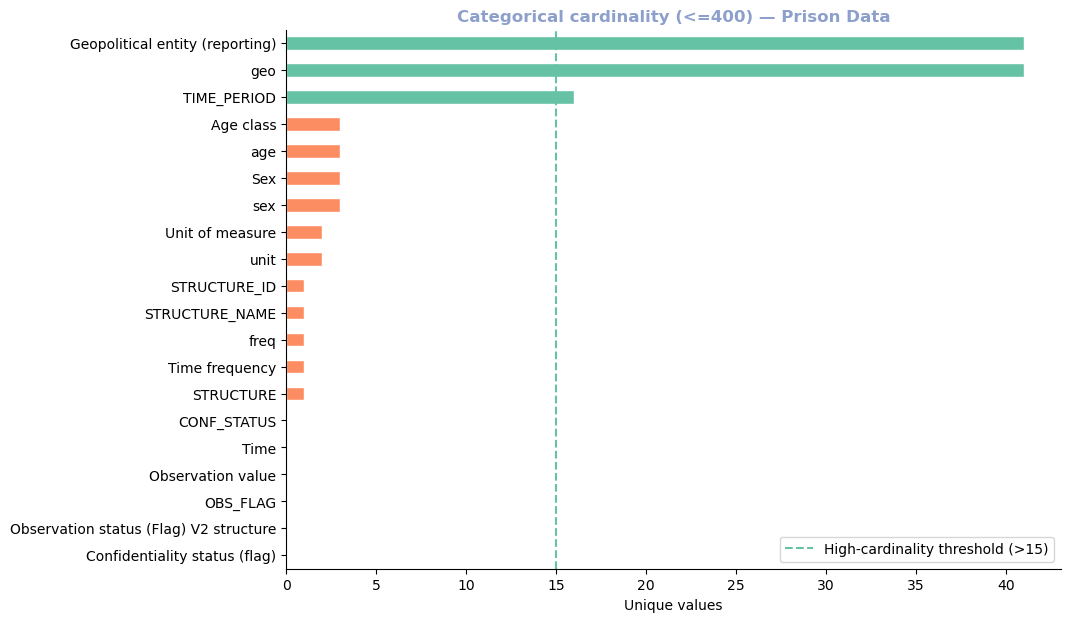

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 6564 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data):
  'Confidentiality status (flag)' (0 values): []

  'Observation status (Flag) V2 structure' (0 values): []

  'OBS_FLAG' (0 values): []

  'Observation value' (0 values): []

  'Time' (0 values): []

  'CONF_STATUS' (0 values): []

  'STRUCTURE' (1 values): ['dataflow']

  'Time frequency' (1 values): ['Annual']

  'freq' (1 values): ['A']

  'STRUCTURE_NAME' (1 values): ['Prisoners by age and sex']

  'STRUCTURE_ID' (1 values): ['ESTAT:CRIM_PRIS_AGE(1.0)']

  'unit' (2 values): ['NR', 'P_HTHAB']

  'Unit of measure' (2 values): ['Number', 'Per hundred thousand inhabitants']

  'sex' (3 values): ['F', 'M', 'T']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'age' (3 values): ['ADULT', 'JUVENILE', 'TOTAL']

  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'TIME_PERIOD' (16 values): ['2008', '2009', '2010', '201

In [71]:
# cardinality of the dataset
YEARS = range(2008, 2024)
PALETTE = sns.color_palette("Set2")
CORAL, STEEL, NAVY = PALETTE[0], PALETTE[1], PALETTE[2]
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(prison_data, "Prison Data")

In [72]:
country_codes = {
    "Albania": "ALB", "Austria": "AUT", "Belgium": "BEL",
    "Bosnia and Herzegovina": "BIH", "Bulgaria": "BGR", "Croatia": "HRV",
    "Cyprus": "CYP", "Czechia": "CZE", "Denmark": "DNK",
    "Estonia": "EST", "Finland": "FIN", "France": "FRA",
    "Germany": "DEU", "Greece": "GRC", "Hungary": "HUN",
    "Iceland": "ISL", "Ireland": "IRL", "Italy": "ITA",
    "Kosovo*": "XKX", "Latvia": "LVA", "Liechtenstein": "LIE",
    "Lithuania": "LTU", "Luxembourg": "LUX", "Malta": "MLT",
    "Montenegro": "MNE", "Netherlands": "NLD", "North Macedonia": "MKD",
    "Norway": "NOR", "Poland": "POL", "Portugal": "PRT",
    "Romania": "ROU", "Serbia": "SRB", "Slovakia": "SVK",
    "Slovenia": "SVN", "Spain": "ESP", "Sweden": "SWE",
    "Switzerland": "CHE", "Türkiye": "TUR",
}
area_km2 = {
    "Albania": 28748, "Austria": 83879, "Belgium": 30689,
    "Bosnia and Herzegovina": 51209, "Bulgaria": 110994, "Croatia": 56594,
    "Cyprus": 9251, "Czechia": 78871, "Denmark": 42952,
    "Estonia": 45339, "Finland": 338455, "France": 643801,
    "Germany": 357596, "Greece": 131957, "Hungary": 93030,
    "Iceland": 102775, "Ireland": 70273, "Italy": 302068,
    "Kosovo*": 10887, "Latvia": 64589, "Liechtenstein": 160,
    "Lithuania": 65300, "Luxembourg": 2586, "Malta": 316,
    "Montenegro": 13812, "Netherlands": 41865, "North Macedonia": 25713,
    "Norway": 385207, "Poland": 312696, "Portugal": 92212,
    "Romania": 238397, "Serbia": 88361, "Slovakia": 49035,
    "Slovenia": 20271, "Spain": 505990, "Sweden": 450295,
    "Switzerland": 41285, "Türkiye": 783562,
}
def get_population_world_bank(iso3_code, start_year=2008, end_year=2023):
    url = (
        f"https://api.worldbank.org/v2/country/{iso3_code}/indicator/SP.POP.TOTL"
        f"?format=json&date={start_year}:{end_year}&per_page=100"
    )
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    data = response.json()[1]
    return {
        int(item["date"]): int(item["value"])
        for item in data
        if item["value"] is not None
    }
country_info = {}
for country, code in country_codes.items():
    country_info[country] = {
        "area_km2": area_km2[country],
        "population_by_year": get_population_world_bank(code, 2008, 2023),
    }
# Manual mapping for regions not in World Bank API
country_info["England and Wales"] = {"area_km2": 151244, "population_by_year": None, "population_fixed": 59641000}
country_info["Scotland (NUTS 2021)"] = {"area_km2": 78803, "population_by_year": None, "population_fixed": 5480000}
country_info["Northern Ireland (UK) (NUTS 2021)"] = {"area_km2": 14333, "population_by_year": None, "population_fixed": 1905000}

# Assign columns after country_info is fully built
prison_data["geo"] = prison_data["Geopolitical entity (reporting)"].map(country_codes)
prison_data["area_km2"] = prison_data["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("area_km2")
)
prison_data["population_by_year"] = prison_data["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_by_year")
)
prison_data["population_fixed"] = prison_data["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_fixed")
)

In [73]:
def resolve_population(row):
    if row["population_fixed"] is not None and not (isinstance(row["population_fixed"], float) and pd.isna(row["population_fixed"])):
        return row["population_fixed"]
    pop_dict = row["population_by_year"]
    if isinstance(pop_dict, dict):
        return pop_dict.get(row["TIME_PERIOD"])
    return None
prison_data["population_year"] = prison_data.apply(resolve_population, axis=1)

prison_data["Per hundred thousand inhabitants"] = prison_data["OBS_VALUE"].where(prison_data["Unit of measure"] == "Per hundred thousand inhabitants")
prison_data["Total"] = prison_data["OBS_VALUE"].where(prison_data["Unit of measure"] == "Number")

# For rows with rate, calculate absolute count
missing_total = prison_data["Total"].isna()
prison_data.loc[missing_total, "Total"] = (prison_data.loc[missing_total, "OBS_VALUE"] * prison_data.loc[missing_total, "population_year"] / 100000).round()

# For rows with count, calculate rate
missing_rate = prison_data["Per hundred thousand inhabitants"].isna()
prison_data.loc[missing_rate, "Per hundred thousand inhabitants"] = (prison_data.loc[missing_rate, "OBS_VALUE"] * 100000 / prison_data.loc[missing_rate, "population_year"]).round(2)

prison_data.sample(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag),area_km2,population_by_year,population_fixed,population_year,Per hundred thousand inhabitants,Total
3937,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,JUVENILE,Juvenile,F,Females,NR,...,NaN,NaN,NaN,NaN,41865,"{2023: 17877117, 2022: 17700982, 2021: 1753304...",NaN,17030314.0,0.08,14.0
8336,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,M,Males,NR,...,NaN,NaN,NaN,NaN,505990,"{2023: 48352528, 2022: 47786102, 2021: 4744382...",NaN,46460733.0,126.55,58798.0
9331,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,NR,...,NaN,NaN,NaN,NaN,28748,"{2023: 2414095, 2022: 2451636, 2021: 2489762, ...",NaN,2528480.0,182.48,4614.0
6424,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,JUVENILE,Juvenile,T,Total,P_HTHAB,...,NaN,NaN,NaN,NaN,83879,"{2023: 9131761, 2022: 9041851, 2021: 8955797, ...",NaN,8879920.0,9.57,850.0
382,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,ADULT,Adult,F,Females,NR,...,NaN,NaN,NaN,NaN,13812,"{2023: 623529, 2022: 623591, 2021: 625053, 202...",NaN,625053.0,4.80,30.0


In [74]:
# Drop columns 
prison_data.drop(columns=[
    'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'age', 'sex',
    'Confidentiality status (flag)', 'OBS_FLAG', 'Observation value', 'Time', 'CONF_STATUS',
    'STRUCTURE', 'Observation status (Flag) V2 structure', 'Unit of measure', 'OBS_VALUE',
    'population_by_year', 'population_fixed'], inplace=True)
# Drop row based on time period 2008 2009 2010 2011 2012 2013
years_to_drop = [2008, 2009, 2010, 2011, 2012, 2013]
prison_data = prison_data[~prison_data["TIME_PERIOD"].isin(years_to_drop)]

prison_data.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Per hundred thousand inhabitants,Total
5073,Juvenile,Males,NLD,Netherlands,2017,41865,17131296.0,2.35,402.0
2606,Adult,Total,HUN,Hungary,2020,93030,9670419.0,171.80,16614.0
7581,Total,Females,ALB,Albania,2015,28748,2731293.0,8.46,231.0
9390,Total,Total,BGR,Bulgaria,2020,110994,6550696.0,95.42,6251.0
3284,Adult,Total,LUX,Luxembourg,2016,2586,582014.0,124.43,724.0


In [75]:
gender_path = Path('../data/Data to export//cleaned_gender_index.csv')
gender_data = pd.read_csv(gender_path)

gender_data = gender_data.melt(
    id_vars='Country', var_name='TIME_PERIOD', value_name='Gender_index'
)
gender_data['TIME_PERIOD'] = gender_data['TIME_PERIOD'].astype(int)
# add a column to prison_data with the gender index for each country and year
prison_data = prison_data.merge(
    gender_data,
    left_on=['Geopolitical entity (reporting)', 'TIME_PERIOD'],
    right_on=['Country', 'TIME_PERIOD'],
    how='left'
).drop(columns='Country')
prison_data.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Per hundred thousand inhabitants,Total,Gender_index
447,Adult,Females,DNK,Denmark,2021,42952,5856733.0,7.75,454.0,0.768
2554,Juvenile,Females,ALB,Albania,2022,28748,2451636.0,0.00,0.0,0.787
507,Adult,Females,HRV,Croatia,2022,56594,3855641.0,12.59,485.0,0.733
5631,Total,Males,LTU,Lithuania,2016,65300,2877325.0,488.34,14051.0,0.744
1916,Adult,Total,GRC,Greece,2016,131957,10775971.0,107.16,11548.0,0.680


In [76]:
# Filter the UE member countries
EU_member = [ "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", 
             "Czechia", "Denmark", "Estonia", "Finland", "France", "Germany", 
             "Greece", "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", 
             "Luxembourg", "Malta", "Netherlands", "Poland", "Portugal", 
             "Romania", "Slovakia", "Slovenia", "Spain", "Sweden"]
prison_data = prison_data[prison_data["Geopolitical entity (reporting)"].isin(EU_member)]


In [77]:
# We separate the row where the 'Age class' and 'Sex' columns have the value 'Total'
total_values = prison_data[(prison_data['Age class'] == 'Total') | (prison_data['Sex'] == 'Total')]
# then drop them from the original dataset
prison_data.drop(total_values.index, inplace=True)
total_values.head(10)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Per hundred thousand inhabitants,Total,Gender_index
1464,Adult,Total,AUT,Austria,2014,83879,8546356.0,100.77,8612.0,0.7266
1465,Adult,Total,AUT,Austria,2015,83879,8642699.0,98.99,8555.0,0.7330
1466,Adult,Total,AUT,Austria,2016,83879,8736668.0,97.33,8503.0,0.7160
1467,Adult,Total,AUT,Austria,2017,83879,8797566.0,99.00,8710.0,0.7090
1468,Adult,Total,AUT,Austria,2018,83879,8840521.0,102.19,9034.0,0.7180
1469,Adult,Total,AUT,Austria,2019,83879,8879920.0,100.51,8925.0,0.7310
1470,Adult,Total,AUT,Austria,2020,83879,8916864.0,94.17,8397.0,0.7440
1471,Adult,Total,AUT,Austria,2021,83879,8955797.0,93.12,8340.0,0.7770
1472,Adult,Total,AUT,Austria,2022,83879,9041851.0,98.48,8904.0,0.7810
1473,Adult,Total,AUT,Austria,2023,83879,9131761.0,98.23,8970.0,0.7400


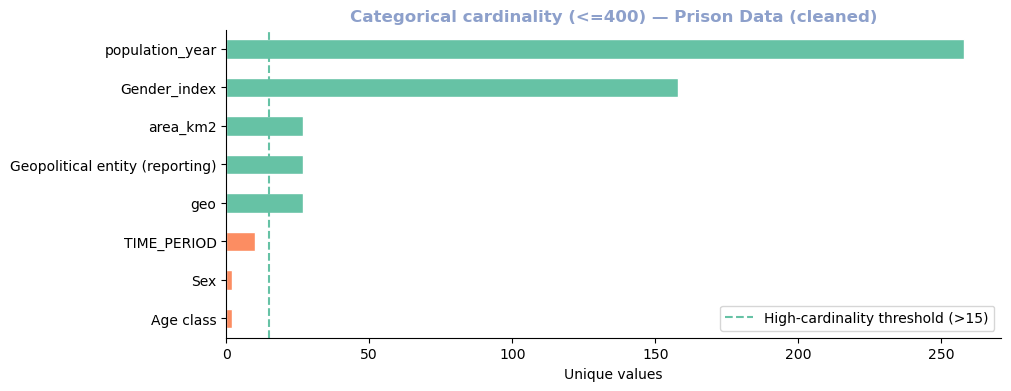

HIGH-CARDINALITY features (excluded from chart):
    'Total': 1270 unique values — needs grouping/target encoding
    'Per hundred thousand inhabitants': 1344 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (cleaned)):
  'Age class' (2 values): ['Adult', 'Juvenile']

  'Sex' (2 values): ['Females', 'Males']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (27 values): ['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']

  'Geopolitical entity (reporting)' (27 values): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia',

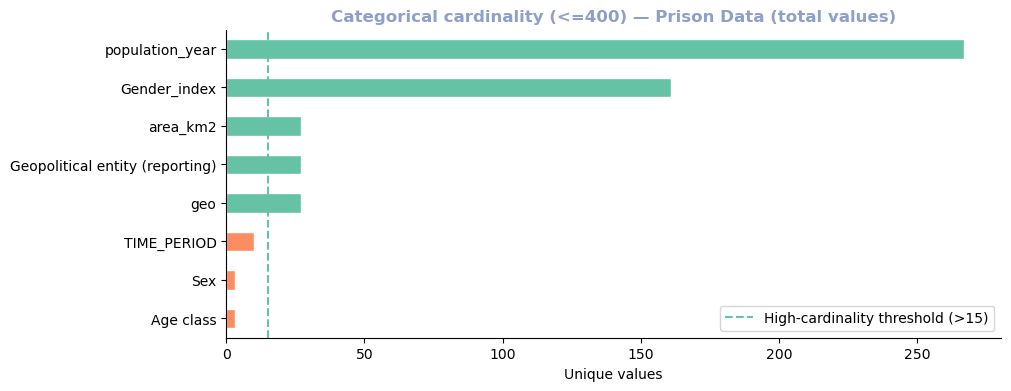

HIGH-CARDINALITY features (excluded from chart):
    'Total': 2150 unique values — needs grouping/target encoding
    'Per hundred thousand inhabitants': 2239 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (total values)):
  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (27 values): ['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']

  'Geopolitical entity (reporting)' (27 values): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 

In [78]:
inspect_categorical(prison_data, "Prison Data (cleaned)")
inspect_categorical(total_values, "Prison Data (total values)")

In [79]:
# Save the cleaned dataset in Data to export folder
prison_data.to_csv('../data/Data to export//cleaned_prison_data.csv', index=False)
total_values.to_csv('../data/Data to export//total_values_prison_data.csv', index=False)